In [1]:
import dill

from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager, StagedPassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling, ASAPScheduleAnalysis
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit.providers.backend import BackendV2 as Backend
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate, YGate
from qiskit.quantum_info import hellinger_fidelity
import numpy as np
import pandas as pd 
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
from qiskit.transpiler.passes import BasisTranslator
from qiskit_ibm_runtime import IBMBackend
from qiskit.visualization import timeline_drawer
from qiskit.transpiler import Target
from qiskit.circuit.library import efficient_su2, QuantumVolume

In [2]:
def prepare_ghz_clean(n_qubits:int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    # circuit.measure_all()

    return circuit

def prepare_echo_ghz_with_xs_clean(n_qubits:int):
    ## Prepares echo circuit with for ghz circuit. Xs at the end to make the expectation value 1. 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.barrier()

    circuit.compose(circuit.inverse(), inplace=True)

    circuit.barrier()

    circuit.x(range(n_qubits))

    # circuit.measure_all()

    return circuit


def quantum_volume_clean(qubit:int, depth:int):

    qc = QuantumVolume(qubit, 2, seed=42069)

    # qc.measure_all()

    return qc


def gen_param4_eff_su2(n_qubits: int, seed: int, reps: int = 1):
    np.random.seed(seed)
    arr = np.random.normal(loc=0, scale=0.22, size=n_qubits*reps*4)
    return arr

def prepare_eff_su2_clean(n_qubits: int, seed_for_params: int):
    crkt = efficient_su2(num_qubits=n_qubits, reps=1, entanglement="linear")
    # crkt.measure_all()
    params = gen_param4_eff_su2(n_qubits, seed_for_params)
    eff_su2_crkt = crkt.assign_parameters(params)

    return eff_su2_crkt


class BenchmarkOptions:
    def __init__(
        self, 
        backend_name: str = "ibm_fez", 
        opt_level: int = 3, 
        do_dd: bool = False,
        scheduling_method: str | None = None, 
        dd_pulse: str | None = None
    ):
        # Allow any backend 
        try:
            self.backend = QiskitRuntimeService().backend(backend_name)
        except Exception as e:
            print(f"Warning: Could not connect to backend '{backend_name}'. {e}")
            self.backend = None

        self.opt_level = opt_level
        self.do_dd = do_dd
        self.dd_pulse = dd_pulse
        self.scheduling_method = scheduling_method
        self.basis_gates = list(self.backend.target.operation_names)

        ## Default pulse sequence is xx
        if self.do_dd and self.dd_pulse is None:
            self.dd_pulse = 'xx'

        


def pm_for_backend(bknd, opt_level:int, seed:int, scheduling_method:str = "none", target:Target | None = None):
    ## Returns a normal (no dd) PassManager from generate_preset_pass_manager for given opt_level and backend(bknd) al
    
    if target is None:
        target = bknd.target
        
    ## for no scheduling case
    if scheduling_method == 'none':
        pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed)
    
    ## for "alap" and "asap" cases
    else:
        pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed, scheduling_method=scheduling_method, target=target)
    
    return pm


def make_passmanager(benchmark_options:BenchmarkOptions):
    
    backend = benchmark_options.backend if benchmark_options.backend else QiskitRuntimeService().backend("ibm_fez")
    opt_level = benchmark_options.opt_level if benchmark_options.opt_level else 3
    scheduling_method = benchmark_options.scheduling_method if benchmark_options.scheduling_method else 'none'

    print(f"Transpilation options:\nbackend:{backend}\noptlevel:{opt_level}\nscheduling:{scheduling_method}\ndo_dd:{benchmark_options.do_dd}\ndd_pulse:{benchmark_options.dd_pulse}")

    ## Fix seed for reprodicubility
    pm_seed = 42069

    ## Include DD
    if benchmark_options.do_dd:
        return prepare_dd_pm(benchmark_options=benchmark_options)

    ## Defaults to no dd PM with opt_level = 3 and given scheduling_method
    else:
        return pm_for_backend(bknd=backend, opt_level=opt_level, seed=pm_seed, scheduling_method=scheduling_method)




def naked_sampler(mode, shots=4096):
    ## Sampler with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    options = SamplerOptions(default_shots=shots, dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
    sampler = Sampler(mode=mode, options=options)
    return sampler

def execute_on_hardware(bknd, sampler_pub):
    ## Batch mode execution of quantum circuits on hardware
    with Batch(backend=bknd) as batch:
        sampler = naked_sampler(mode=batch, shots=4096)
        # summary = summarize_backend(bknd)
        job = sampler.run(sampler_pub)
        id = job.job_id()
        print(id)
    return id


def get_result_from_id(service, id):
    # Get Result object from service using id

    job = service.job(id)
    result = job.result()

    return result
    

def prepare_dd_pm(benchmark_options:BenchmarkOptions):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 

    # Default Sequence
    sequenece = [XGate(), XGate()]

    target = benchmark_options.backend.target

    seq = benchmark_options.dd_pulse

    if seq.lower() == "xpxm":
        sequenece = [XGate(), XGate().inverse()]

    if seq.lower() == 'xy':
        from qiskit.transpiler import InstructionProperties

        sequenece = [XGate(), YGate(), XGate(), YGate()]

        y_gate_properties = {}

        for qubit in range(target.num_qubits):
            y_gate_properties.update(
                {
                    (qubit,): InstructionProperties(
                        duration=target["x"][(qubit,)].duration,
                        error=target["x"][(qubit,)].error,
                    )
                }
            )
        
        target.add_instruction(YGate(), y_gate_properties)

    


    ## Prepare a preset passmanager for backend optimization_level=3 and target (target is modified if seq = 'xy)
    pm = pm_for_backend(bknd=benchmark_options.backend, opt_level=3, seed=42069, target=target)

    try:
            
        if benchmark_options.scheduling_method:    
                if benchmark_options.scheduling_method == 'asap':
                    pm.scheduling.append(ASAPScheduleAnalysis(target=target))
                    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))
                
                elif benchmark_options.scheduling_method == 'alap':
                    pm.scheduling.append(ALAPScheduleAnalysis(target=target))
                    pm.scheduling.append(PadDynamicalDecoupling(target=target, dd_sequence=sequenece))

    except:
        print(f"Error in sequence({seq}) or scheduling method({benchmark_options.scheduling_method})")

    return pm




def mega_transpiler(circuit:QuantumCircuit, dd_pm:StagedPassManager, benchmark_options:BenchmarkOptions) -> QuantumCircuit:
    
    isa_dd_circuit = dd_pm.run(circuit)
    
    ## Final Translation to convert Y gates into basis equivalent gates
    if benchmark_options.do_dd is True:
        if benchmark_options.dd_pulse.lower() == 'xy':
            from qiskit.circuit.equivalence_library import (SessionEquivalenceLibrary as sel,)
            from qiskit.transpiler.passes import BasisTranslator
            

            basis_gates = benchmark_options.basis_gates
            

            return BasisTranslator(sel, basis_gates)(isa_dd_circuit)
        else:
            return isa_dd_circuit

    ## Normal case for xx dd and xpxm dd
    else:
        return isa_dd_circuit
    



def get_fidelity_for_circuit(simulated, dd_counts_list):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    
    # 1 :- List of len 2 with hellinger fidelity compared to simulated counts. [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in dd_counts_list:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [alt_hellinger_results]




    


In [3]:
# 2. Save Function (Generic for any object)
def save_object(obj, filename):
    try:
        with open(filename, 'wb') as f:
            dill.dump(obj, f)
        print(f"Object saved to '{filename}'")
    except Exception as e:
        print(f"Error saving object: {e}")

# 3. Load Function
def load_object(filename):
    try:
        with open(filename, 'rb') as f:
            obj = dill.load(f)
        print(f"Object loaded from '{filename}'")
        return obj
    except Exception as e:
        print(f"Error loading object: {e}")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from qiskit import transpile, QuantumCircuit
from qiskit.visualization import plot_gate_map


def get_backend_metrics(backend):
    """
    Extracts T1, T2, and Gate Errors (Coupling Quality) from the backend.
    """
    target = backend.target
    num_qubits = backend.num_qubits
    
    # 1. Extract T1 and T2 for every qubit
    t1_times    = []
    t2_times    = []
    DD_qubits   = {"good": [], "bad": [], "ugly": []}
    gate_errors = {'x':[], 'sx':[], 'measure':[], 'rz':[]}
    
    
    for i in range(num_qubits):

        ## Separate qubits accoriding to DD fitness
        try:
            # Get t1, t2 values (values are usually in seconds)
            props = backend.qubit_properties(i)
            t1_times.append(props.t1)
            t2_times.append(props.t2)

            ## Getting all the gate error each index of the list corresponds to qubit number
            for gate in list(gate_errors.keys()):
                gate_errors[gate].append(target[gate][(i,)].error)
            
            ## window of tolerance
            ugly_start = 1.3
            bad_start = 0.8

            ## The Ugly
            if (ugly_start)*props.t1 < props.t2:
                DD_qubits['ugly'].append(i)

            ## The bad : Currently defining randomly but shall make better later...
            elif ugly_start*props.t1 >= props.t2 and bad_start*props.t1 <= props.t2:
                DD_qubits['bad'].append(i)

            ## The Good
            else:
                DD_qubits['good'].append(i)

        except:
            t1_times.append(0)
            t2_times.append(0)

        
    gate_errors['cz'] = dict()
    # 2. Extract Coupling Error (Proxy for ZZ/Connection Quality)
    # We look for the 'ecr' or 'cx' gate error between coupled pairs
    coupling_map = target.build_coupling_map()
    
    
    # Find the dominant 2-qubit gate (usually 'ecr' or 'cz')
    two_q_gate = 'ecr' if 'ecr' in target.operation_names else 'cz'
    
    for edge in coupling_map:
        try:
            # Get error rate for the specific edge
            props = target[two_q_gate].get(edge)
            error = props.error if props else 1.0
            gate_errors['cz'][tuple(edge)] = error
        except:
            gate_errors['cz'][tuple(edge)] = 1.0

    return {
        "name": backend.name,
        "t1": np.array(t1_times),
        "t2": np.array(t2_times),
        "gate_errors": gate_errors,
        "coupling_map": coupling_map,
        "DD_qubits":DD_qubits
        }

# Initialize a backend (Replace this with your real service.backend("ibm_brisbane"))
service = QiskitRuntimeService()
fez = service.backend("ibm_fez")
metrics = get_backend_metrics(fez)

print(f"Extracted data for {fez.name}:")
print(f"Avg T1: {np.mean(metrics['t1'])*1e6:.2f} µs")
print(f"Avg T2: {np.mean(metrics['t2'])*1e6:.2f} µs")

# print(f"Avg Coupling Error: {np.mean(list(metrics['coupling_errors'].values())):.4f}")

management.get:WARNING:2025-12-21 13:57:32,556: Loading default saved account


Extracted data for ibm_fez:
Avg T1: 141.09 µs
Avg T2: 101.98 µs


In [5]:
def get_backend_map_with_circuit(backend_metrics, circuit:QuantumCircuit | None = None):
    from qiskit_ibm_runtime import QiskitRuntimeService
    ## Buliding colormap for qubits and connections
    qubit_color = []
    for i in range(len(backend_metrics['t1'])):
        if i in backend_metrics['DD_qubits']['ugly']:
            qubit_color.append("black")
        elif i in backend_metrics['DD_qubits']['bad']:
            qubit_color.append("orange") 
        else:
            qubit_color.append("grey") 
    line_color = []
    for e in backend_metrics["coupling_map"].get_edges():
        line_color.append("black") 
    
    if circuit is not None:
    ## Now for the circuit qubits
        circuit_qubits = circuit.layout.final_index_layout()

        for qubit in circuit_qubits:
            try:
                if qubit in backend_metrics['DD_qubits']['bad'] or qubit in backend_metrics['DD_qubits']['ugly']:
                    qubit_color[qubit] = "#973018"
                    
                else:
                    qubit_color[qubit] = "#239A47"

            except IndexError:
                print("Your circuit contains qubits not on the backend. Recheck circuit.layout for more info")

    backend = QiskitRuntimeService().backend(backend_metrics["name"])
        
    return plot_gate_map(backend, qubit_color=qubit_color, line_color=line_color, qubit_size=50, font_size=25, figsize=(14,14))

## Load Circuits

In [6]:
qubits = [i for i in range(2, 50)]

ghz_dict = {qubit:prepare_ghz_clean(qubit) for qubit in qubits}
echo_ghz_dict = {qubit:prepare_echo_ghz_with_xs_clean(qubit) for qubit in qubits}
su2_dict = {qubit:prepare_eff_su2_clean(qubit, 42069) for qubit in qubits}
qv_dict  = {qubit:quantum_volume_clean(qubit, depth=2) for qubit in qubits}

/tmp/ipykernel_6890/3945712913.py:34: DeprecationWarning: The class ``qiskit.circuit.library.quantum_volume.QuantumVolume`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.quantum_volume instead.
  qc = QuantumVolume(qubit, 2, seed=42069)
/tmp/ipykernel_6890/3945712913.py:34: DeprecationWarning: The class ``qiskit.circuit.library.quantum_volume.QuantumVolume`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.quantum_volume instead.
  qc = QuantumVolume(qubit, 2, seed=42069)


In [7]:
## Setting the benchmark conditions
benchmark_options = BenchmarkOptions(backend_name='ibm_fez', opt_level=3, do_dd=False, scheduling_method='alap')


management.get:WARNING:2025-12-21 13:57:47,063: Loading default saved account


In [8]:
passmanager = make_passmanager(benchmark_options=benchmark_options)

Transpilation options:
backend:<IBMBackend('ibm_fez')>
optlevel:3
scheduling:alap
do_dd:False
dd_pulse:None


In [9]:
isa_ghz_dict = {qubit:passmanager.run(ghz_dict[qubit]) for qubit in qubits}
isa_echo_ghz_dict = {qubit:passmanager.run(echo_ghz_dict[qubit]) for qubit in qubits}
isa_su2_dict = {qubit:passmanager.run(su2_dict[qubit]) for qubit in qubits}
isa_qv_dict = {qubit:passmanager.run(qv_dict[qubit]) for qubit in qubits}

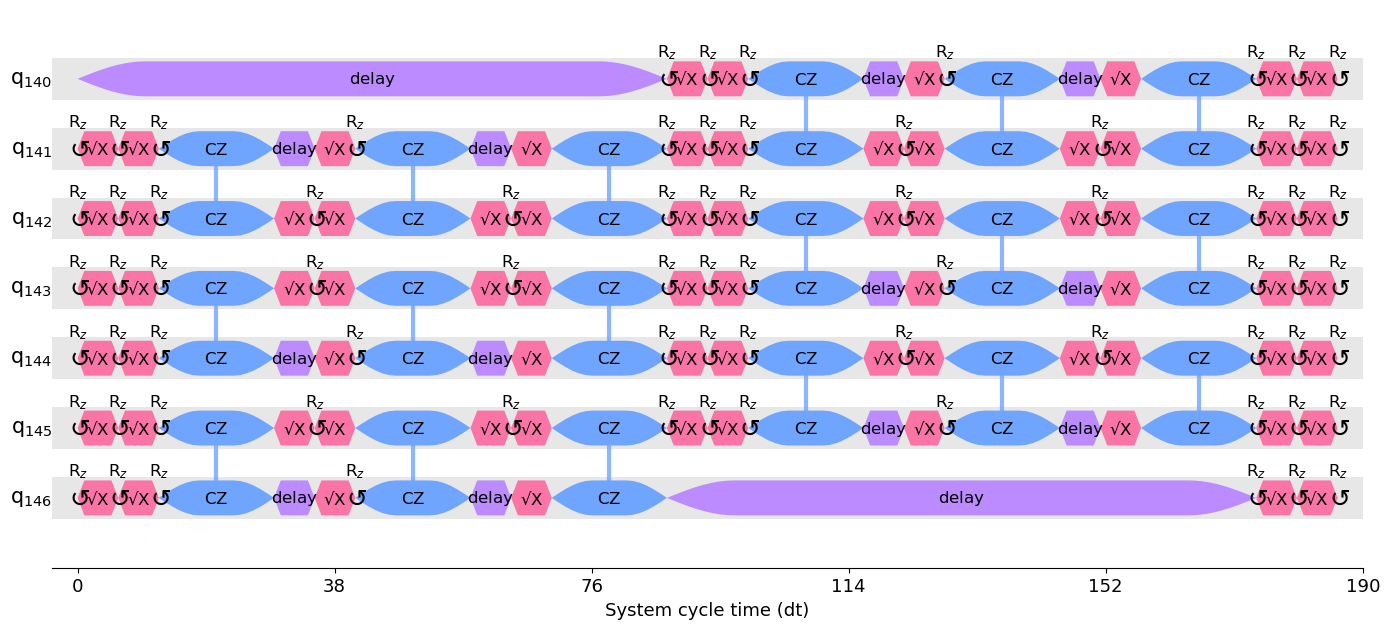

In [19]:
timeline_drawer(isa_qv_dict[7], target=fez.target, idle_wires=False, show_delays=True)

In [ ]:
from qiskit.circuit import Delay
from qiskit.circuit import Instruction

## This is for proper circuit analysis

def get_circuit_features_asap(circuit:QuantumCircuit, backend):
    # Give transpiled + scheduled(asap) circuit only
    active_qubits = circuit.layout.final_index_layout()

    total_duration = circuit.duration

    instruction_durations = backend.instruction_durations

    busy_qubits = {qubit:0 for qubit in active_qubits}
    idle_qubits = {qubit:0 for qubit in active_qubits}
    
    for instruction in circuit.data:
        # If instr is Delay. filter complete idle and idle between gates qubit
        operation = instruction.operation
        if isinstance(operation, Delay):
            if operation.duration == total_duration:
                pass
            # Delay on working qubit
            else:
                # print(operation)
                idle_qubits[instruction.qubits[0]._index] += operation.duration
                
        elif isinstance(operation, Instruction):
            # Measurement or barrier need to be filtered
            if operation.name in ['measure', 'barrier']:
                continue
            else:
                # for two qubit op
                if len(instruction.qubits) == 2:
                    op_str = operation.name
                    # print(op_str)
                    qubit0 = instruction.qubits[0]._index
                    qubit1 = instruction.qubits[1]._index
                    busy_qubits[qubit0] += instruction_durations.get(qubits=[qubit0, qubit1], inst=op_str)
                    busy_qubits[qubit1] += instruction_durations.get(qubits=[qubit0, qubit1], inst=op_str)
                
                # for one qubit op
                else:
                    op_str = operation.name
                    # print(op_str)
                    qubit0 = instruction.qubits[0]._index
                    busy_qubits[qubit0] += instruction_durations.get(qubits=[qubit0], inst=op_str)




    return busy_qubits, idle_qubits, total_duration




In [ ]:
from qiskit.converters import circuit_to_dag
def circuit_analysis(circuit:QuantumCircuit, backend):

    dag_circuit = circuit_to_dag(circuit)

    return dag_circuit



In [111]:



def circuit_analysis(circuit):

    active_qubits = circuit.layout.final_index_layout()

    delays_list = []
    idle_qubits = {}


    # print(active_qubits)

    test_dag = circuit_to_dag(circuit)

    total_duration = circuit.duration

    for node in test_dag.op_nodes():
        op = node.op
        
        qubits = [q._index for q in node.qargs]

        if isinstance(op, Delay):
            if qubits[0] in active_qubits:
                # print("This has delay")
                try:
                    idle_qubits[qubits[0]] += op.duration
                    delays_list.append(op.duration)
                except KeyError:
                    continue

        elif isinstance(op, Instruction):
            for qubit in qubits:
                idle_qubits[qubit] = 0
            
    

    return np.mean(delays_list), np.std(delays_list)

circuit_analysis(isa_ghz_dict[7])

/tmp/ipykernel_11568/739670065.py:13: DeprecationWarning: The property ``qiskit.circuit.quantumcircuit.QuantumCircuit.duration`` is deprecated as of Qiskit 1.3.0. It will be removed in Qiskit 3.0.0.
  total_duration = circuit.duration


(63.5, 39.27997793617846)

In [114]:
def plot_idle_time_vs_qubits(circuit_dict, ax):

    data_list = []
    qubits = list(circuit_dict.keys())
    for qubit in qubits:
        mean, std = circuit_analysis(circuit_dict[qubit])
        data_list.append((mean, std))

    
    ax.errorbar(qubits, [data_list[i][0] for i in range(len(data_list))], yerr=[data_list[i][1] for i in range(len(data_list))], fmt='o')

    return ax


/tmp/ipykernel_11568/739670065.py:13: DeprecationWarning: The property ``qiskit.circuit.quantumcircuit.QuantumCircuit.duration`` is deprecated as of Qiskit 1.3.0. It will be removed in Qiskit 3.0.0.
  total_duration = circuit.duration


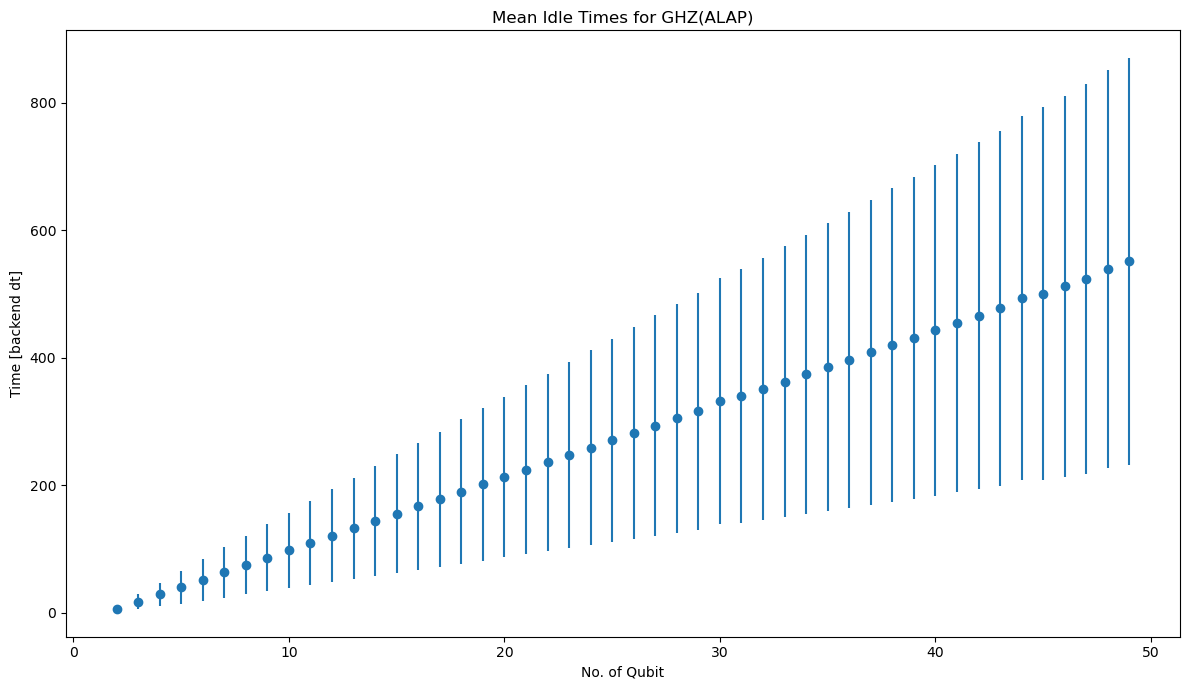

In [115]:
fig, ax = plt.subplots(figsize=(12, 7))

plot_idle_time_vs_qubits(isa_ghz_dict, ax)

ax.set_title("Mean Idle Times for GHZ(ALAP)")
ax.set_ylabel("Time [backend dt]")
ax.set_xlabel("No. of Qubit")
fig.tight_layout()


/tmp/ipykernel_11568/739670065.py:13: DeprecationWarning: The property ``qiskit.circuit.quantumcircuit.QuantumCircuit.duration`` is deprecated as of Qiskit 1.3.0. It will be removed in Qiskit 3.0.0.
  total_duration = circuit.duration


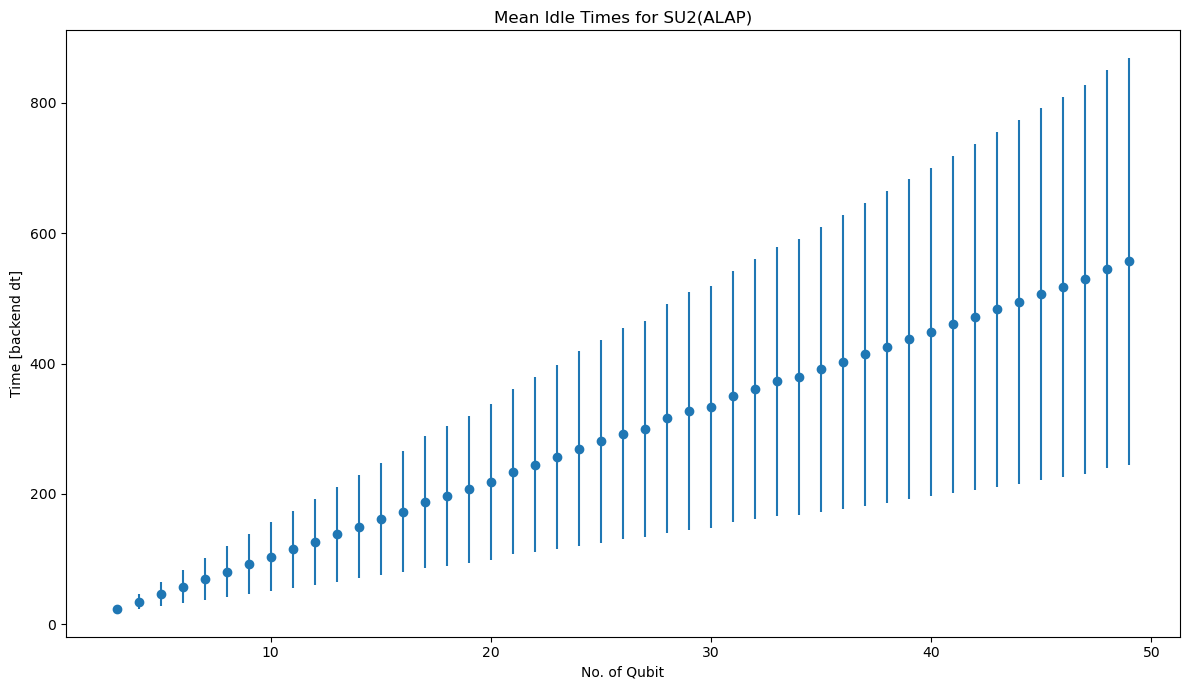

In [118]:
fig, ax = plt.subplots(figsize=(12, 7))

plot_idle_time_vs_qubits(isa_su2_dict, ax)

ax.set_title("Mean Idle Times for SU2(ALAP)")
ax.set_ylabel("Time [backend dt]")
ax.set_xlabel("No. of Qubit")
fig.tight_layout()

/tmp/ipykernel_11568/739670065.py:13: DeprecationWarning: The property ``qiskit.circuit.quantumcircuit.QuantumCircuit.duration`` is deprecated as of Qiskit 1.3.0. It will be removed in Qiskit 3.0.0.
  total_duration = circuit.duration


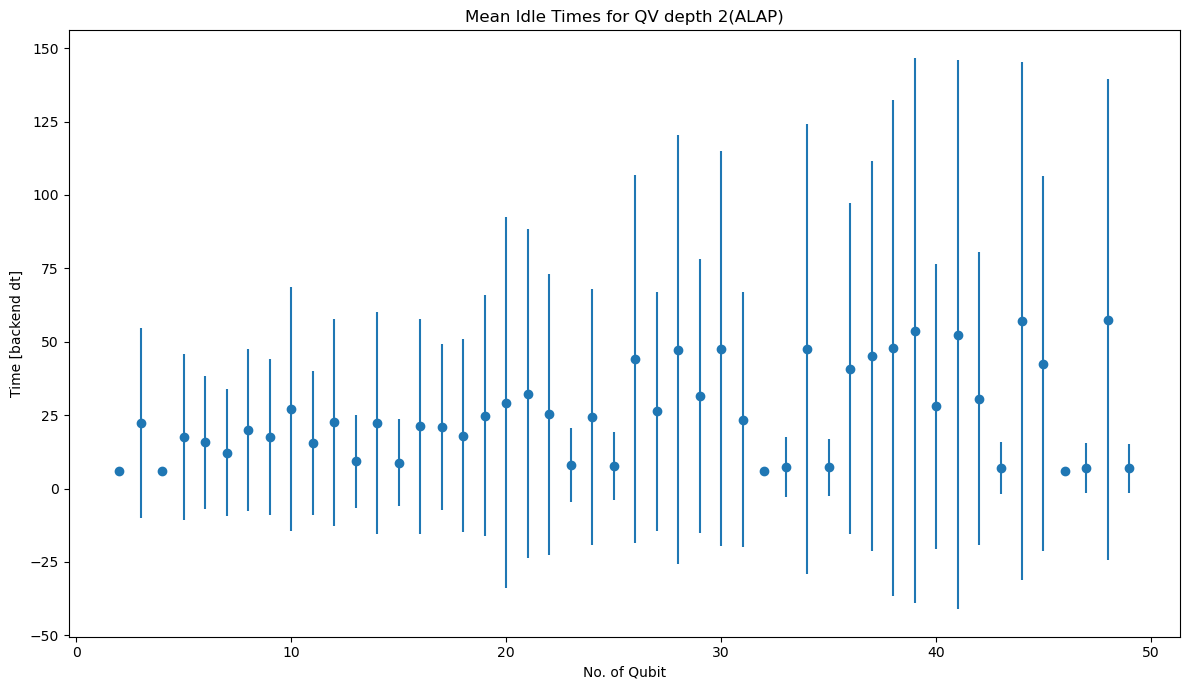

In [119]:
fig, ax = plt.subplots(figsize=(12, 7))

plot_idle_time_vs_qubits(isa_qv_dict, ax)

ax.set_title("Mean Idle Times for QV depth 2(ALAP)")
ax.set_ylabel("Time [backend dt]")
ax.set_xlabel("No. of Qubit")
fig.tight_layout()

In [122]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import ParameterVector

def create_lucj_layer(qc, num_qubits, layer_idx, params):
    """
    Applies one layer of the LUCJ ansatz (Local Unitary Cluster Jastrow).
    This consists of a 'Hop' layer (XX+YY) and an 'Interaction' layer (ZZ/nn),
    arranged in a brick-wall pattern to respect linear connectivity.
    """
    param_idx = 0
    
    # --- 1. Orbital Rotation / Hopping Part (Givens Rotations: XX+YY) ---
    # We apply these in an even-odd pattern to depth 2 for parallel execution
    for parity in [0, 1]:
        for i in range(parity, num_qubits - 1, 2):
            # XX+YY interaction (equivalent to a Partial Swap or Fermionic simulation gate)
            # In Qiskit, we can approximate this with RXX and RYY
            theta = params[param_idx]
            qc.rxx(theta, i, i+1)
            qc.ryy(theta, i, i+1)
            param_idx += 1

    # --- 2. Interaction / Jastrow Part (Diagonal Coulomb: ZZ or nn) ---
    # We apply these in an even-odd pattern
    for parity in [0, 1]:
        for i in range(parity, num_qubits - 1, 2):
            # ZZ interaction (Correlation)
            phi = params[param_idx]
            qc.rzz(phi, i, i+1)
            # Note: A full 'nn' gate also includes single qubit Z rotations, 
            # but RZZ is the core two-qubit entangling part of the Jastrow term.
            param_idx += 1
            
    return param_idx

def initialize_lucj_circuit(num_qubits, layers=1):
    """
    Initializes a LUCJ circuit for a specific number of qubits.
    """
    # Calculate number of parameters needed
    # (num_qubits - 1) pairs * 2 (even/odd steps) * 2 (Hop + Interaction phases) ??
    # Actually: In a linear chain of N qubits, there are N-1 links.
    # Each link gets a Hop (theta) and an Interaction (phi).
    # Total params per layer = 2 * (N - 1)
    
    num_params = layers * 2 * (num_qubits - 1)
    params = ParameterVector(f'θ_Q{num_qubits}', num_params)
    
    qc = QuantumCircuit(num_qubits, name=f"LUCJ_Ansatz_{num_qubits}Q")
    
    current_param_idx = 0
    for l in range(layers):
        # Slice the parameters for this layer
        layer_params = params[current_param_idx:] 
        used = create_lucj_layer(qc, num_qubits, l, layer_params)
        current_param_idx += used
        qc.barrier() # Optional: to visualize layers
        
    return qc

# --- Execution for requested qubit numbers ---

qubit_counts = [i for i in range(2, 50)]
lucj_dict = {}

print(f"{'Qubits':<10} | {'Circuit Name':<25} | {'Gates (Approx)':<15} | {'Depth':<10}")
print("-" * 70)

for n in qubit_counts:
    # Initialize with 1 layer (L=1) for demonstration
    qc = initialize_lucj_circuit(n, layers=1)
    lucj_dict[n] = passmanager.run(qc)
    
    # Basic metrics
    n_gates = sum(qc.count_ops().values())
    depth = qc.depth()
    
    print(f"{n:<10} | {qc.name:<25} | {n_gates:<15} | {depth:<10}")

# Example: Draw the smallest circuit to verify structure
print("\n--- Visualizing 5-Qubit LUCJ Circuit Structure (Layer 1) ---")
print(lucj_dict[5].draw(output='text'))

Qubits     | Circuit Name              | Gates (Approx)  | Depth     
----------------------------------------------------------------------
2          | LUCJ_Ansatz_2Q            | 4               | 3         
3          | LUCJ_Ansatz_3Q            | 7               | 6         
4          | LUCJ_Ansatz_4Q            | 10              | 6         
5          | LUCJ_Ansatz_5Q            | 13              | 6         
6          | LUCJ_Ansatz_6Q            | 16              | 6         
7          | LUCJ_Ansatz_7Q            | 19              | 6         
8          | LUCJ_Ansatz_8Q            | 22              | 6         
9          | LUCJ_Ansatz_9Q            | 25              | 6         
10         | LUCJ_Ansatz_10Q           | 28              | 6         
11         | LUCJ_Ansatz_11Q           | 31              | 6         
12         | LUCJ_Ansatz_12Q           | 34              | 6         
13         | LUCJ_Ansatz_13Q           | 37              | 6         
14         | LUCJ_A

/tmp/ipykernel_11568/739670065.py:13: DeprecationWarning: The property ``qiskit.circuit.quantumcircuit.QuantumCircuit.duration`` is deprecated as of Qiskit 1.3.0. It will be removed in Qiskit 3.0.0.
  total_duration = circuit.duration


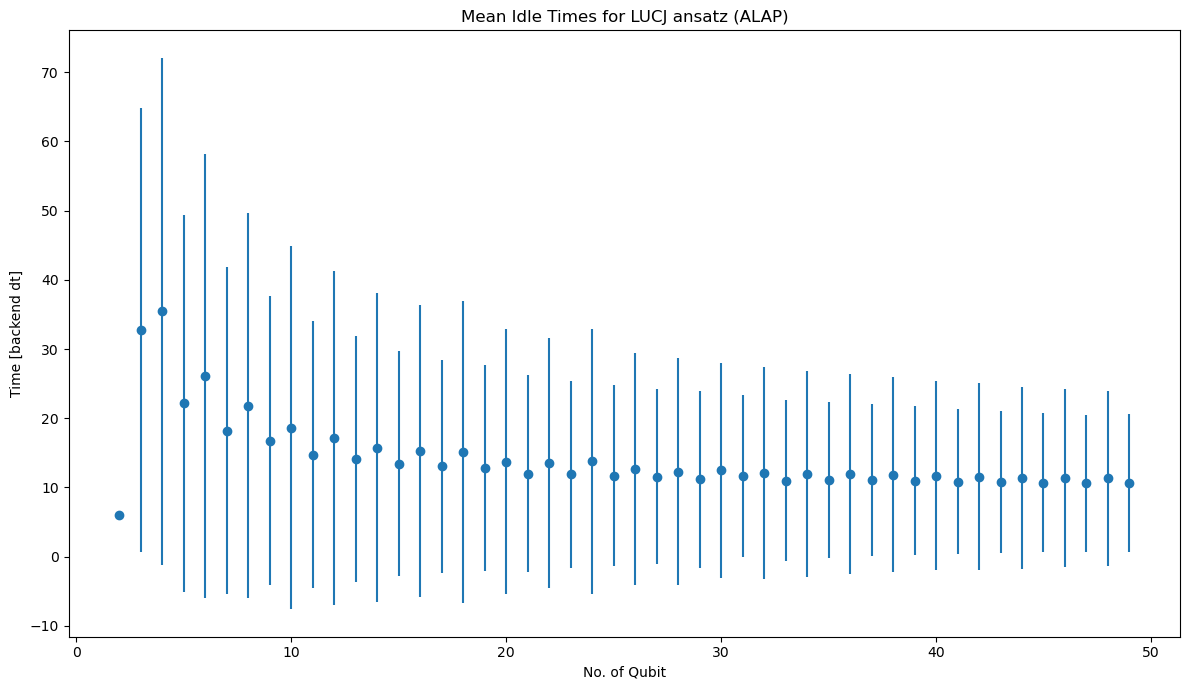

In [124]:
fig, ax = plt.subplots(figsize=(12, 7))

plot_idle_time_vs_qubits(lucj_dict, ax)

ax.set_title("Mean Idle Times for LUCJ ansatz (ALAP)")
ax.set_ylabel("Time [backend dt]")
ax.set_xlabel("No. of Qubit")
fig.tight_layout()

In [42]:
busy, idle, total = get_circuit_features_asap(isa_qv_dict[7], backend=fez)
print(f"busy_dict {busy}\nidle_dict {idle}\ntotal time {total}")

busy_dict {142: 186, 143: 174, 144: 174, 140: 87, 141: 174, 145: 174, 146: 87}
idle_dict {142: 0, 143: 12, 144: 12, 140: 99, 141: 12, 145: 12, 146: 99}
total time 186


/tmp/ipykernel_11568/2520896014.py:10: DeprecationWarning: The property ``qiskit.circuit.quantumcircuit.QuantumCircuit.duration`` is deprecated as of Qiskit 1.3.0. It will be removed in Qiskit 3.0.0.
  total_duration = circuit.duration


In [43]:
busy, idle, total = get_circuit_features_alap(isa_qv_dict[7], backend=fez)
print(f"busy_dict {busy}\nidle_dict {idle}\ntotal time {total}")

busy_dict {140: 87, 141: 174, 142: 186, 143: 174, 144: 174, 145: 174, 146: 87}
idle_dict {140: 99, 141: 12, 144: 12, 143: 12, 146: 99, 145: 12}
total time 186


/tmp/ipykernel_11568/2520896014.py:67: DeprecationWarning: The property ``qiskit.circuit.quantumcircuit.QuantumCircuit.duration`` is deprecated as of Qiskit 1.3.0. It will be removed in Qiskit 3.0.0.
  total_duration = circuit.duration


management.get:WARNING:2025-12-18 20:30:45,209: Loading default saved account


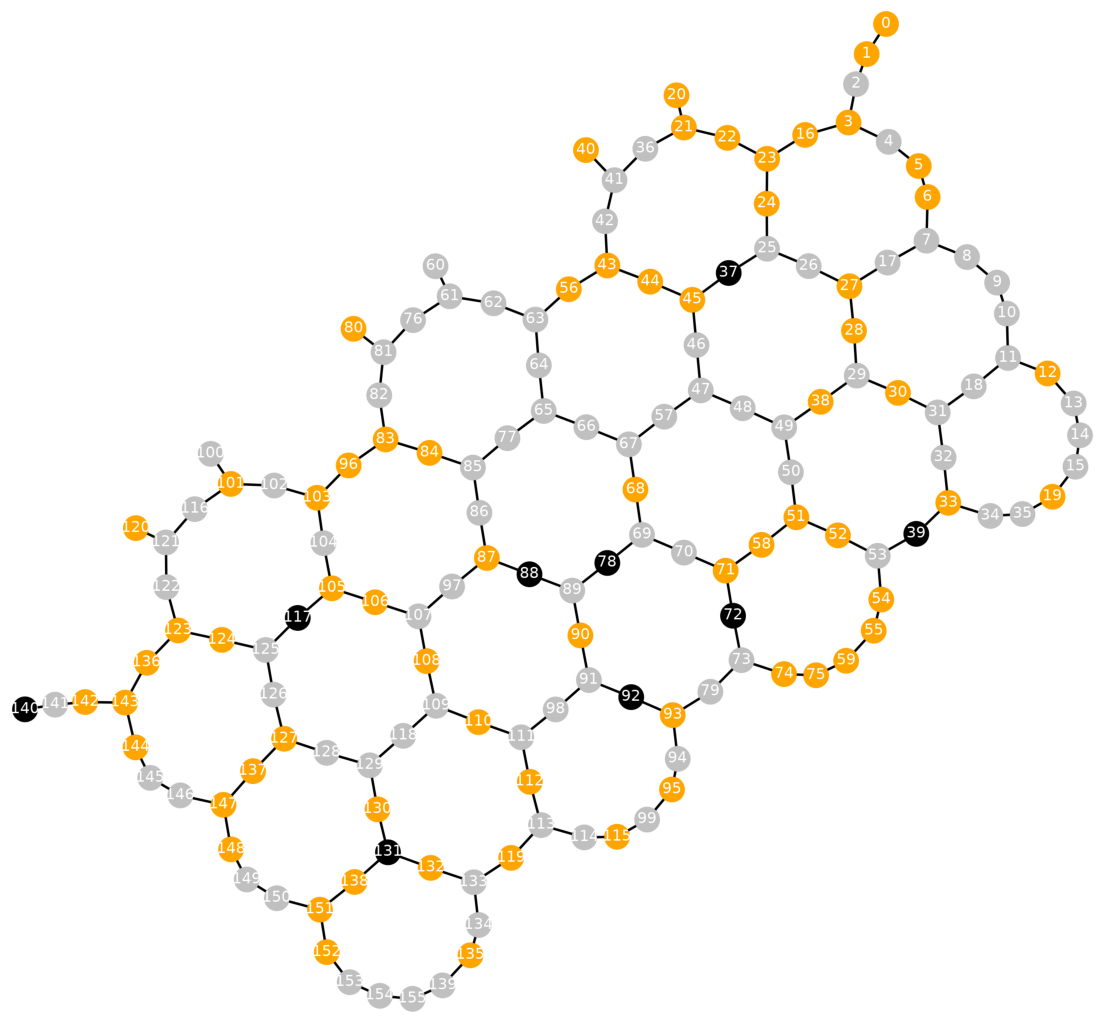

In [13]:
get_backend_map_with_circuit(metrics)

In [14]:
isa_ghz_dict

{7: {'none': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7059e41e5590>,
  'asap': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7059b0157110>,
  'alap': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7059b0011610>,
  'asap+dd+xx': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7059afed79d0>,
  'alap+dd+xx': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7059b00a6690>,
  'alap+dd+xpxm': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7059afd32f90>,
  'asap+dd+xpxm': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7059afcb3fd0>,
  'asap+dd+xy': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7059afe3a210>,
  'alap+dd+xy': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7059afee5850>},
 8: {'none': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7059b001df90>,
  'asap': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7059af822290>,
  'alap': <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x7059af874090>,
  'asap+dd+xx': <qiskit.circuit.quantumci

# Analysing circuit times

In [78]:
key = -20

print(isa_ghz_dict[7]["alap"].data[key])

isa_ghz_dict[7]["alap"].data[key].qubits[0]._index

CircuitInstruction(operation=Instruction(name='cz', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(156, "q"), index=147>, <Qubit register=(156, "q"), index=137>), clbits=())


147

In [ ]:
fez.instruction_durations.get(qubits=[0], inst='')

0

In [82]:
get_circuit_features(isa_ghz_dict[7]["alap"], fez)

rz
sx
rz
Delay(duration=120[unit=dt])
rz
sx
rz
rz
sx
rz
cz
Delay(duration=126[unit=dt])
sx
rz
Delay(duration=23[unit=dt])
rz
sx
rz
cz
Delay(duration=103[unit=dt])
sx
rz
Delay(duration=46[unit=dt])
rz
sx
rz
cz
Delay(duration=80[unit=dt])
sx
rz
Delay(duration=69[unit=dt])
rz
sx
rz
cz
Delay(duration=57[unit=dt])
sx
rz
Delay(duration=92[unit=dt])
rz
sx
rz
cz
Delay(duration=29[unit=dt])
sx
rz
cz
sx
rz
Delay(duration=6[unit=dt])


/tmp/ipykernel_3956/3371391816.py:7: DeprecationWarning: The property ``qiskit.circuit.quantumcircuit.QuantumCircuit.duration`` is deprecated as of Qiskit 1.3.0. It will be removed in Qiskit 3.0.0.
  total_duration = circuit.duration


({136: 23, 143: 46, 144: 46, 145: 46, 146: 51, 147: 51, 137: 29},
 {136: 126, 143: 103, 144: 103, 145: 103, 146: 98, 147: 98, 137: 120},
 539)

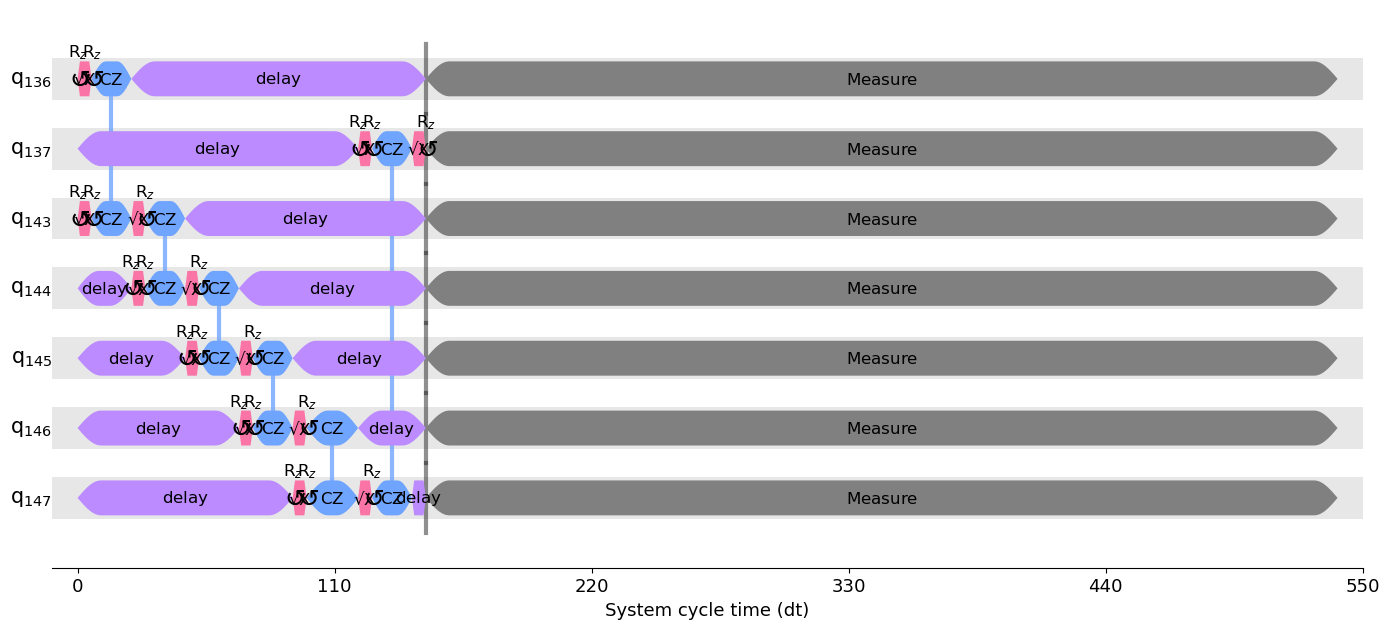

In [ ]:
timeline_drawer(isa_ghz_dict[7]["none"], target=fez.target, idle_wires=False, show_delays=True)

In [54]:
from typing import Dict, Tuple, Any
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_dag
from qiskit.circuit import Delay

def get_circuit_features(
    qc: QuantumCircuit, backend: Any
) -> Tuple[Dict[int, float], Dict[int, float], Dict[int, float]]:
    """
    Calculates total duration, busy time, and idle time for physical qubits in the circuit.
    
    Args:
        qc: The quantum circuit (must be transpiled and have a final_index_layout).
        backend: The backend instance (used for duration lookup if needed).
        
    Returns:
        Three dictionaries: (total_duration, busy_time, idle_time)
        Keys are physical qubit indices.
    """
    # Ensure layout is available
    if qc.layout is None or qc.layout.final_index_layout() is None:
        raise ValueError("Circuit must be transpiled and have a final_index_layout.")
        
    # Get the set of physical qubits we are interested in
    # final_index_layout() maps logical qubits to physical indices (int)
    interested_physical_qubits = qc.layout.final_index_layout()
    
    # Map circuit qubits to physical indices
    # In a transpiled circuit, qc.qubits are typically ordered by physical index
    qubit_to_physical_index = {q: i for i, q in enumerate(qc.qubits)}
    
    # Initialize result dictionaries
    total_duration = {i: 0.0 for i in interested_physical_qubits}
    busy_time = {i: 0.0 for i in interested_physical_qubits}
    idle_time = {i: 0.0 for i in interested_physical_qubits}
    
    dag = circuit_to_dag(qc)
    
    for node in dag.op_nodes():
        op = node.op
        
        # Determine duration
        duration = op.duration
        
        # If duration is not explicitly set, try to fetch from backend
        if duration is None and backend is not None:
            try:
                # Map node qubits to physical indices
                indices = tuple(qubit_to_physical_index[q] for q in node.qargs)
                if hasattr(backend, "target") and backend.target:
                    if op.name in backend.target:
                        props = backend.target[op.name].get(indices)
                        if props is not None:
                            duration = props.duration
            except Exception:
                pass
        
        # Default to 0 if still None (e.g. Barriers)
        if duration is None:
            duration = 0.0
            
        # Add duration to relevant qubits
        for q in node.qargs:
            if q in qubit_to_physical_index:
                phys_idx = qubit_to_physical_index[q]
                
                # Only track metrics for qubits in the final layout
                if phys_idx in interested_physical_qubits:
                    total_duration[phys_idx] += duration
                    
                    if isinstance(op, Delay):
                        idle_time[phys_idx] += duration
                    else:
                        busy_time[phys_idx] += duration
                        
    return total_duration, busy_time, idle_time


In [55]:
get_circuit_features(isa_ghz_dict[7]["alap"], fez)

AttributeError: 'RZGate' object has no attribute 'duration'